In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import re
import string

# MERGE DATA

In [ ]:
import os

# List of CSV files to merge
csv_files = [
    '/content/drive/MyDrive/Capstone MIKTI Kelompok 1/Dataset_Pilkada_Jatim/Dataset_Scraping (kotor)/clean_data_pilkada_pilkada_1992.csv',
    '/content/drive/MyDrive/Capstone MIKTI Kelompok 1/Dataset_Pilkada_Jatim/Dataset_Scraping (kotor)/clean_scraping_detik_pilkada_jatim.csv'
]

# Create an empty list to store the dataframes
dfs = []

# Iterate through the CSV files and read them into dataframes
for file in csv_files:
  if os.path.exists(file):
    try:
      # Specify the encoding as 'latin-1' to handle the problematic byte sequence
      df = pd.read_csv(file, encoding='latin-1')
      dfs.append(df)
    except pd.errors.EmptyDataError:
      print(f"Warning: {file} is empty. Skipping this file.")
    except pd.errors.ParserError:
      print(f"Warning: Could not parse {file}. Check file format. Skipping this file.")
  else:
    print(f"Warning: {file} not found. Skipping this file.")


# Concatenate all dataframes into a single dataframe
merged_df = pd.concat(dfs, ignore_index=True)

# Save the merged dataframe to a new CSV file
merged_df.to_csv('scraping_dataset_pilkada_jatim_new.csv', index=False)

print("Merged CSV file created successfully.")

Merged CSV file created successfully.


# GATHERING DATA

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Capstone MIKTI Kelompok 1/Dataset_Pilkada_Jatim/new_clean_data_pilkada_2057.csv')
df

,title,publish_date
0,PKS Jatim siap lanjutkan kolaborasi dengan Kho...,"Sabtu, 30 Nov 2024 06:08 WIB"
1,Tasyakuran dan doa bersama anak yatim atas Kem...,"Jumat, 29 Nov 2024 15:29 WIB"
2,Tasyakuran dan doa bersama anak yatim atas Kem...,"Jumat, 29 Nov 2024 08:10 WIB"
3,Khofifah-Emil Raih 70 Persen Suara Di Pilgub J...,"Jumat, 29 Nov 2024 04:45 WIB"
4,Quick count Poltracking: Khofifah-Emil unggul ...,"Kamis, 28 Nov 2024 10:48 WIB"
...,...,...
2053,"Hasil Pilkada 2024 di Mojokerto, Khofifah dan ...","Kamis, 05 Dec 2024 21:59 WIB"
2054,PKB Usung Kader Maju Pilgub Jatim: Luluk Nur H...,"Rabu, 28 Aug 2024 10:26 WIB"
2055,Luluk Nur Hamidah Ingin Bangun KRL di Madura R...,"Senin, 18 Nov 2024 21:09 WIB"
2056,"Maju Pilgub Jatim, Luluk Hamidah Serahkan Sura...","Senin, 02 Sep 2024 14:28 WIB"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         2058 non-null   object
 1   publish_date  2058 non-null   object
dtypes: object(2)
memory usage: 32.3+ KB


In [ ]:
df.dtypes

,0
title,object
publish_date,object


In [ ]:
df.shape

(2058, 2)

# CHECK NULL & DUPLICATED DATA

In [ ]:
df.isnull().sum()

,0
title,0
publish_date,0


In [ ]:
df.duplicated().sum()

0

# DATA CLEANING & FILTERS



In [ ]:
df['publish_date'] = df['publish_date'].astype(str).str.replace(r'^\w+, ', '', regex=True).str.replace(' WIB', '')

df['publish_date'] = pd.to_datetime(df['publish_date'], format='%d %b %Y %H:%M', errors='coerce')

df['year'] = df['publish_date'].dt.year
df['month'] = df['publish_date'].dt.month
df['date'] = df['publish_date'].dt.day
df['day'] = df['publish_date'].dt.day_name()
df['time'] = df['publish_date'].dt.time

df

,title,publish_date,year,month,date,day,time
0,PKS Jatim siap lanjutkan kolaborasi dengan Kho...,2024-11-30 06:08:00,2024,11,30,Saturday,06:08:00
1,Tasyakuran dan doa bersama anak yatim atas Kem...,2024-11-29 15:29:00,2024,11,29,Friday,15:29:00
2,Tasyakuran dan doa bersama anak yatim atas Kem...,2024-11-29 08:10:00,2024,11,29,Friday,08:10:00
3,Khofifah-Emil Raih 70 Persen Suara Di Pilgub J...,2024-11-29 04:45:00,2024,11,29,Friday,04:45:00
4,Quick count Poltracking: Khofifah-Emil unggul ...,2024-11-28 10:48:00,2024,11,28,Thursday,10:48:00
...,...,...,...,...,...,...,...
2053,"Hasil Pilkada 2024 di Mojokerto, Khofifah dan ...",2024-12-05 21:59:00,2024,12,5,Thursday,21:59:00
2054,PKB Usung Kader Maju Pilgub Jatim: Luluk Nur H...,2024-08-28 10:26:00,2024,8,28,Wednesday,10:26:00
2055,Luluk Nur Hamidah Ingin Bangun KRL di Madura R...,2024-11-18 21:09:00,2024,11,18,Monday,21:09:00
2056,"Maju Pilgub Jatim, Luluk Hamidah Serahkan Sura...",2024-09-02 14:28:00,2024,9,2,Monday,14:28:00


In [ ]:
def preprocess_text(kalimat):
    if isinstance(kalimat, str):
        # Mengubah kalimat menjadi huruf kecil
        lower_case = kalimat.lower()

        # Menghapus angka, tanda baca tertentu (-, :), dan karakter aneh
        hasil = re.sub(r'[,()\d\-:]+', '', lower_case)
        hasil = re.sub(r'[^\x00-\x7F]+', ' ', hasil)  # Menghapus karakter non-ASCII

        # Menghapus hashtag, mention, dan URL
        hasil = re.sub(r'#\w+', '', hasil)
        hasil = re.sub(r'@\w+', '', hasil)
        hasil = re.sub(r'(?:\@|http?\://|https?\://|www)\S+', '', hasil)

        # Menghapus tanda baca dari kalimat
        hasil = hasil.translate(str.maketrans('', '', string.punctuation))

        # Menghapus spasi pada awal dan akhir kalimat
        hasil = hasil.strip()

        # Mengganti karakter HTML dengan spasi
        hasil = re.sub('<.*?>', ' ', hasil)

        # Mempertimbangkan huruf dan angka
        hasil = re.sub('[^a-zA-Z0-9]', ' ', hasil)

        # Mengganti line baru dengan spasi
        hasil = re.sub("\n", " ", hasil)

        # Menghapus single char
        hasil = re.sub(r"\b[a-zA-Z]\b", " ", hasil)

        # Memisahkan dan menggabungkan kata
        hasil = ' '.join(hasil.split())

        return hasil
    else:
        return kalimat

In [ ]:
# DO PREPROCESSING
df['title'] = df['title'].apply(preprocess_text)
df.head(20)

,title,publish_date,year,month,date,day,time
0,pks jatim siap lanjutkan kolaborasi dengan kho...,2024-11-30 06:08:00,2024,11,30,Saturday,06:08:00
1,tasyakuran dan doa bersama anak yatim atas kem...,2024-11-29 15:29:00,2024,11,29,Friday,15:29:00
2,tasyakuran dan doa bersama anak yatim atas kem...,2024-11-29 08:10:00,2024,11,29,Friday,08:10:00
3,khofifahemil raih persen suara di pilgub jatim...,2024-11-29 04:45:00,2024,11,29,Friday,04:45:00
4,quick count poltracking khofifahemil unggul di...,2024-11-28 10:48:00,2024,11,28,Thursday,10:48:00
5,quick count poltracking pilgub jatim persen kh...,2024-11-28 07:54:00,2024,11,28,Thursday,07:54:00
6,jokowi ucapkan selamat kepada khofifahemil ata...,2024-11-28 05:12:00,2024,11,28,Thursday,05:12:00
7,khofifahemil unggul telak di quick count pilgu...,2024-11-27 14:46:00,2024,11,27,Wednesday,14:46:00
8,khofifahemil unggul di jatim jokowi langsung t...,2024-11-27 13:15:00,2024,11,27,Wednesday,13:15:00
9,lia istifhama paslon gubernur khofifahemil dip...,2024-11-27 04:44:00,2024,11,27,Wednesday,04:44:00


# LABELING

In [ ]:
def label_words_in_dataframe(df, column_name, filename):
    labels_df = pd.read_csv(filename)

    # Ubah DataFrame menjadi dictionary
    keyword_to_label = labels_df.set_index('keyword')['label'].to_dict()
    labeled_data = []

    for sentence in df[column_name]:
        # Pisahkan kalimat menjadi kata-kata
        words = sentence.split(' ')
        # Inisialisasi list kosong untuk menyimpan label kata dalam kalimat
        labels = []
        # Iterasi melalui kata-kata dalam kalimat
        for word in words:
            # Jika kata adalah kata kunci, berikan label yang sesuai
            if word in keyword_to_label:
                labels.append(keyword_to_label[word])

        # Gabungkan label menjadi string dan tambahkan ke data yang telah diberi label
        labeled_data.append(' '.join(labels))

    # Tambahkan data yang telah diberi label sebagai kolom baru ke DataFrame Anda
    df['category'] = labeled_data

    return df

In [ ]:
# MELAKUKAN LABELING

filename = '/content/drive/MyDrive/Capstone MIKTI Kelompok 1/Dataset_Pilkada_Jatim/label_map_pilkada_jatim.csv'
df['title'] = df['title'].astype(str) # Convert the column to string type
df = label_words_in_dataframe(df, 'title', filename)
df.head(20)

,title,publish_date,year,month,date,day,time,category
0,pks jatim siap lanjutkan kolaborasi dengan kho...,2024-11-30 06:08:00,2024,11,30,Saturday,06:08:00,Paslon 2
1,tasyakuran dan doa bersama anak yatim atas kem...,2024-11-29 15:29:00,2024,11,29,Friday,15:29:00,Paslon 2
2,tasyakuran dan doa bersama anak yatim atas kem...,2024-11-29 08:10:00,2024,11,29,Friday,08:10:00,Paslon 2
3,khofifahemil raih persen suara di pilgub jatim...,2024-11-29 04:45:00,2024,11,29,Friday,04:45:00,Paslon 2
4,quick count poltracking khofifahemil unggul di...,2024-11-28 10:48:00,2024,11,28,Thursday,10:48:00,Paslon 2 Paslon 2
5,quick count poltracking pilgub jatim persen kh...,2024-11-28 07:54:00,2024,11,28,Thursday,07:54:00,Paslon 2
6,jokowi ucapkan selamat kepada khofifahemil ata...,2024-11-28 05:12:00,2024,11,28,Thursday,05:12:00,Paslon 2
7,khofifahemil unggul telak di quick count pilgu...,2024-11-27 14:46:00,2024,11,27,Wednesday,14:46:00,Paslon 2
8,khofifahemil unggul di jatim jokowi langsung t...,2024-11-27 13:15:00,2024,11,27,Wednesday,13:15:00,Paslon 2
9,lia istifhama paslon gubernur khofifahemil dip...,2024-11-27 04:44:00,2024,11,27,Wednesday,04:44:00,Paslon 2


# LIBRARY IMPLEMENTATION

In [ ]:
 Sastrawi
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.4 MB/s eta 0:00:00


In [ ]:
from warnings import filterwarnings
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.colors as mcolors
import numpy as np
import nltk
import seaborn as sns
import plotly.express as px
from plotly import graph_objs as go
from PIL import Image
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
from textblob import Word, TextBlob
from wordcloud import WordCloud

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# TOKENIZING

In [ ]:
def tokenize_text(kalimat):
    if isinstance(kalimat, str):
        tokens = nltk.tokenize.word_tokenize(kalimat)
        return tokens
    else:
        return []

df['token'] = df['title'].fillna('').apply(tokenize_text)
df.head()

,title,publish_date,year,month,date,day,time,category,token
0,pks jatim siap lanjutkan kolaborasi dengan kho...,2024-11-30 06:08:00,2024,11,30,Saturday,06:08:00,Paslon 2,"[pks, jatim, siap, lanjutkan, kolaborasi, deng..."
1,tasyakuran dan doa bersama anak yatim atas kem...,2024-11-29 15:29:00,2024,11,29,Friday,15:29:00,Paslon 2,"[tasyakuran, dan, doa, bersama, anak, yatim, a..."
2,tasyakuran dan doa bersama anak yatim atas kem...,2024-11-29 08:10:00,2024,11,29,Friday,08:10:00,Paslon 2,"[tasyakuran, dan, doa, bersama, anak, yatim, a..."
3,khofifahemil raih persen suara di pilgub jatim...,2024-11-29 04:45:00,2024,11,29,Friday,04:45:00,Paslon 2,"[khofifahemil, raih, persen, suara, di, pilgub..."
4,quick count poltracking khofifahemil unggul di...,2024-11-28 10:48:00,2024,11,28,Thursday,10:48:00,Paslon 2 Paslon 2,"[quick, count, poltracking, khofifahemil, ungg..."


# DATA VISUALIZATION

In [ ]:
#filter kata
words_to_count = ["Paslon 1", "Paslon 2", "Paslon 3"]
# Convert 'Keterangan' column to lowercase for case-insensitive counting
df['category'] = df['category'].str.lower()

# Count occurrences of each word
word_counts = {word: df['category'].str.count(word.lower()).sum() for word in words_to_count}

# Display the counts for each word
for word, count in word_counts.items():
    print(f"The word '{word}' appears {count} times.")

The word 'Paslon 1' appears 216 times.
The word 'Paslon 2' appears 1309 times.
The word 'Paslon 3' appears 903 times.


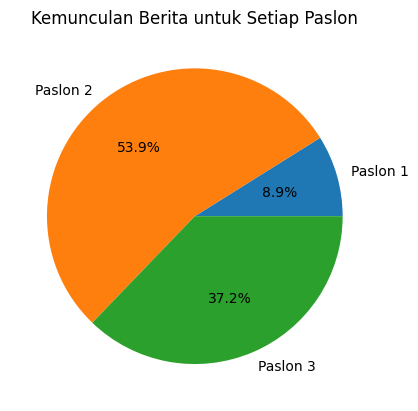

In [ ]:
# Calculate the total count
total_count = sum(word_counts.values())

# Calculate the percentages
percentages = [count/total_count * 100 for count in word_counts.values()]

# Plot the pie chart
plt.pie(percentages, labels=word_counts.keys(), autopct='%1.1f%%')
plt.title('Kemunculan Berita untuk Setiap Paslon')
plt.show()

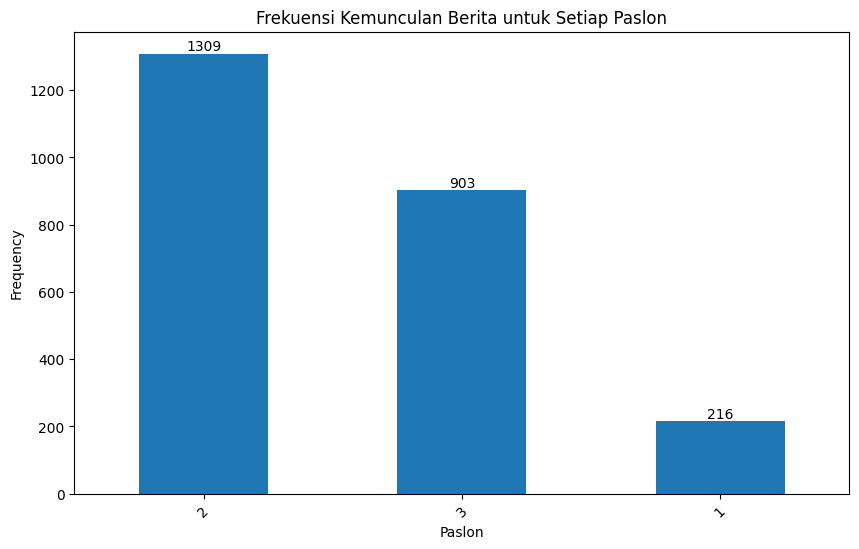

In [ ]:
word_counts = (df['category'].str.split().explode()
                              .value_counts()
                              .sort_values(ascending=False)
                              .drop('paslon'))

# Plotting the word frequency
plt.figure(figsize=(10, 6))
ax = word_counts[:20].plot(kind='bar')  # Get the Axes object for label placement
#word_counts[:20].plot(kind='bar')
plt.xlabel('Paslon')
plt.ylabel('Frequency')
plt.title('Frekuensi Kemunculan Berita untuk Setiap Paslon')
plt.xticks(rotation=45)
# Add value labels above each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",  # Format the value as an integer
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Place label above the bar
                ha='center', va='bottom')
plt.show()

In [ ]:
# Hitung banyaknya berita group by bulan

count_df = df.groupby(['month']).size().reset_index(name='title_count')
sorted_df = count_df.sort_values(by=['month'])
print(sorted_df)

    month  title_count
0       1            3
1       2           11
2       3           10
3       4           25
4       5           85
5       6          112
6       7          116
7       8          277
8       9          310
9      10          481
10     11          612
11     12           16


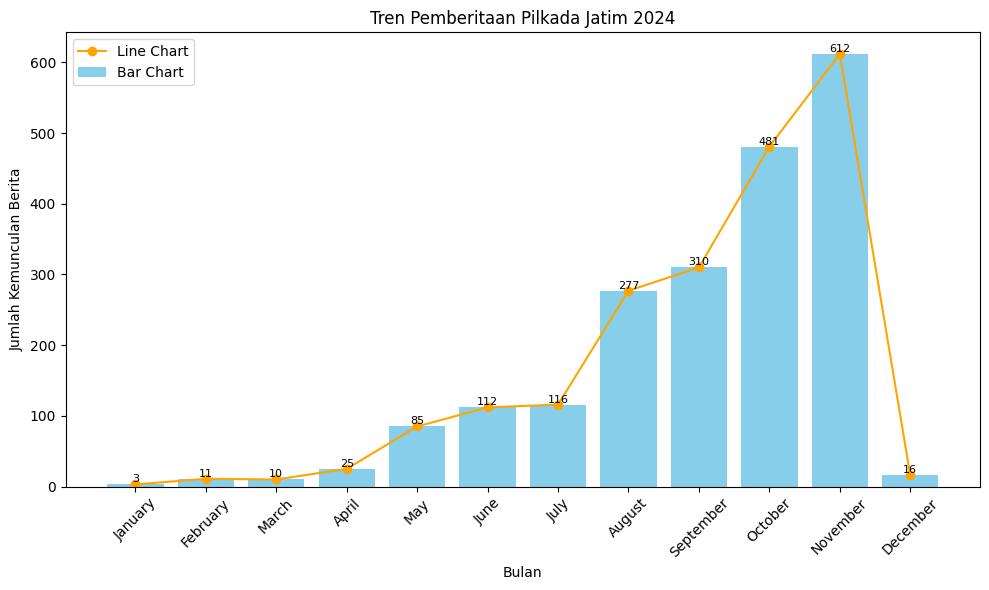

In [ ]:
# Mapping month numbers to full month names
month_mapping = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

plt.figure(figsize=(10, 6))

# Plotting the bar chart
bars = plt.bar(sorted_df['month'], sorted_df['title_count'], color='skyblue', label='Bar Chart')

# Plotting the line chart
plt.plot(sorted_df['month'], sorted_df['title_count'], marker='o', linestyle='-', color='orange', label='Line Chart')

plt.xlabel('Bulan')
plt.ylabel('Jumlah Kemunculan Berita')
plt.title('Tren Pemberitaan Pilkada Jatim 2024')
#plt.xticks(rotation=45)
plt.xticks(sorted_df.index + 1, [month_mapping[i] for i in sorted_df.index + 1], rotation=45)

# Adding labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom', fontsize=8)

plt.legend()  # Show legend
plt.tight_layout()
plt.show()

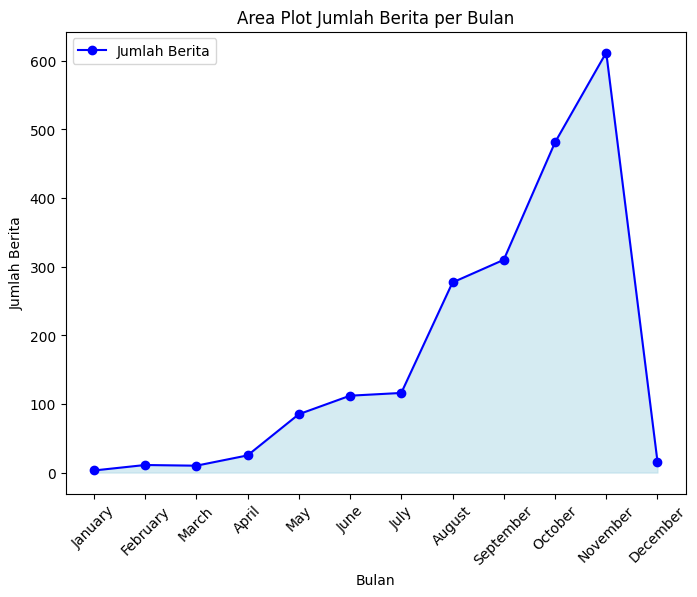

In [ ]:
# Additional Visualization: Area Plot
plt.figure(figsize=(8, 6))
plt.fill_between(sorted_df['month'], sorted_df['title_count'], color='lightblue', alpha=0.5)
plt.plot(sorted_df['month'], sorted_df['title_count'], color='blue', marker='o', label='Jumlah Berita')
plt.title('Area Plot Jumlah Berita per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Berita')
plt.xticks(sorted_df.index + 1, [month_mapping[i] for i in sorted_df.index + 1], rotation=45)
plt.legend()
plt.show()

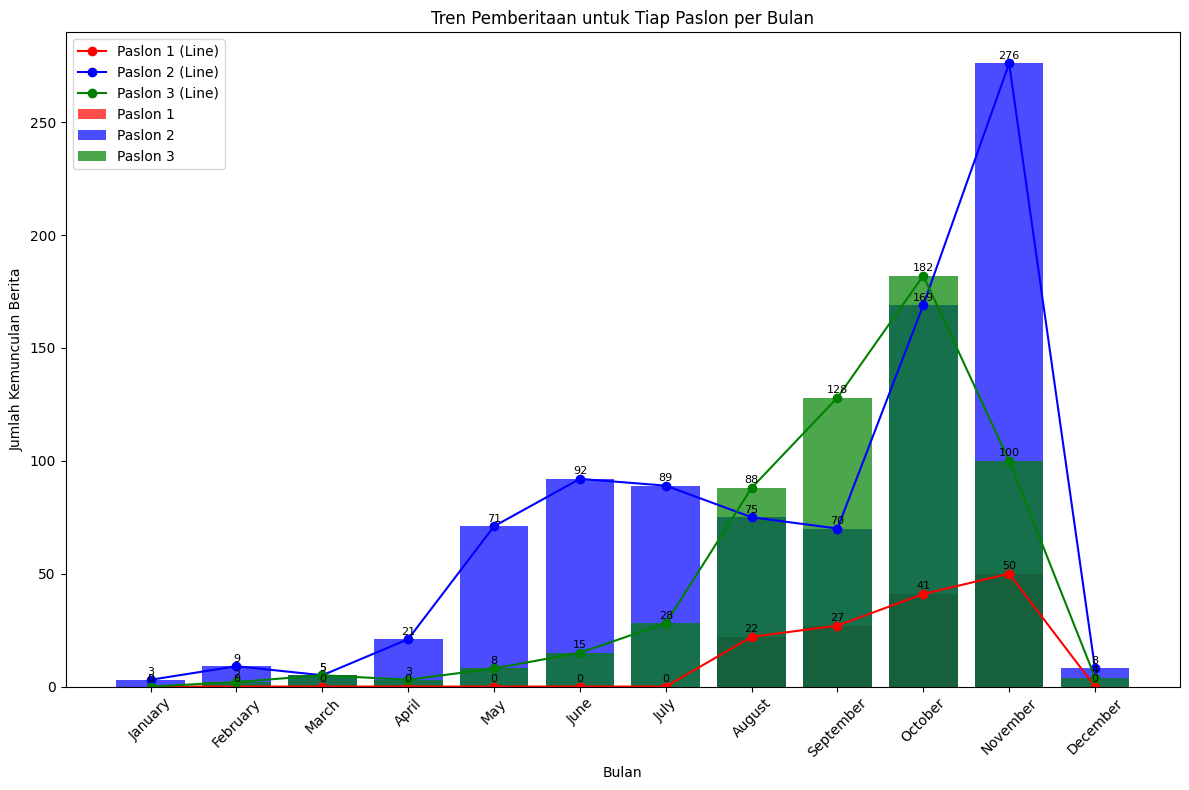

In [ ]:
# Filter kata
words_to_count = ["Paslon 1", "Paslon 2", "Paslon 3"]
df['category'] = df['category'].str.lower()

# Group by month and count occurrences for each paslon
monthly_counts = {word: df[df['category'].str.contains(word.lower())].groupby(df['month']).size() for word in words_to_count}

# Convert to DataFrame and fill missing months with 0
monthly_counts_df = pd.DataFrame(monthly_counts).fillna(0).reset_index()
monthly_counts_df.columns = ['month'] + words_to_count

# Sort by month
monthly_counts_df = monthly_counts_df.sort_values('month')

# Plotting
plt.figure(figsize=(12, 8))

# Plotting the bar chart for each paslon with specified colors
colors = {'Paslon 1': 'red', 'Paslon 2': 'blue', 'Paslon 3': 'green'}  # Define colors for each paslon
for word in words_to_count:
    plt.bar(monthly_counts_df['month'], monthly_counts_df[word], label=word, alpha=0.7, color=colors[word])

# Plotting the line chart for each paslon with specified colors
for word in words_to_count:
    plt.plot(monthly_counts_df['month'], monthly_counts_df[word], marker='o', linestyle='-', label=f"{word} (Line)", color=colors[word])

# Adding month names to x-axis
plt.xticks(monthly_counts_df['month'], [month_mapping[m] for m in monthly_counts_df['month']], rotation=45)

# Labels, title, and legend
plt.xlabel('Bulan')
plt.ylabel('Jumlah Kemunculan Berita')
plt.title('Tren Pemberitaan untuk Tiap Paslon per Bulan')
plt.legend()
plt.tight_layout()

# Adding labels on top of bars
for i in range(len(monthly_counts_df)):
    for word in words_to_count:
        value = monthly_counts_df.loc[i, word]
        plt.text(x=monthly_counts_df.loc[i, 'month'], y=value + 2, s=f"{int(value)}", ha='center', fontsize=8)

plt.show()

# STOPWORDS

In [ ]:
# Buat StopWordRemover baru dengan kamus stop words tambahan
more_stop_words = ['quick', 'count', 'undecided', 'video', 'cabup', 'caugb']
stop_words = StopWordRemoverFactory().get_stop_words() + more_stop_words
new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopword_text(tokens):
    # Gabungkan token menjadi string untuk diproses oleh Sastrawi
    text = " ".join(tokens)

    # Hapus stop words menggunakan Sastrawi
    cleaned_text = stop_words_remover_new.remove(text)

    # Pisahkan kembali string menjadi token
    cleaned_tokens = cleaned_text.split()

    return cleaned_tokens

df['token_clean'] = df['token'].apply(stopword_text)

In [ ]:
df['token_clean'].head(20)

,token_clean
0,"[pks, jatim, siap, lanjutkan, kolaborasi, khof..."
1,"[tasyakuran, doa, bersama, anak, yatim, atas, ..."
2,"[tasyakuran, doa, bersama, anak, yatim, atas, ..."
3,"[khofifahemil, raih, persen, suara, pilgub, ja..."
4,"[count, poltracking, khofifahemil, unggul, pil..."
5,"[count, poltracking, pilgub, jatim, persen, kh..."
6,"[jokowi, ucapkan, selamat, khofifahemil, atas,..."
7,"[khofifahemil, unggul, telak, quick, pilgub, j..."
8,"[khofifahemil, unggul, jatim, jokowi, langsung..."
9,"[lia, istifhama, paslon, gubernur, khofifahemi..."


# STEMMING

In [ ]:
# Proses stemming setelah stopword removal
stemmer = StemmerFactory().create_stemmer()

def stemming(tokens):
    # Terapkan stemming per kata dan kembalikan dalam bentuk list
    return [stemmer.stem(word) for word in tokens]

df['token_clean'] = df['token_clean'].apply(stemming)

In [ ]:
df['token_clean'].head(20)

,token_clean
0,"[pks, jatim, siap, lanjut, kolaborasi, khofifa..."
1,"[tasyakur, doa, sama, anak, yatim, atas, menan..."
2,"[tasyakur, doa, sama, anak, yatim, atas, menan..."
3,"[khofifahemil, raih, persen, suara, pilgub, ja..."
4,"[count, poltracking, khofifahemil, unggul, pil..."
5,"[count, poltracking, pilgub, jatim, persen, kh..."
6,"[jokowi, ucap, selamat, khofifahemil, atas, me..."
7,"[khofifahemil, unggul, telak, quick, pilgub, j..."
8,"[khofifahemil, unggul, jatim, jokowi, langsung..."
9,"[lia, istifhama, paslon, gubernur, khofifahemi..."


# WORD CLOUD

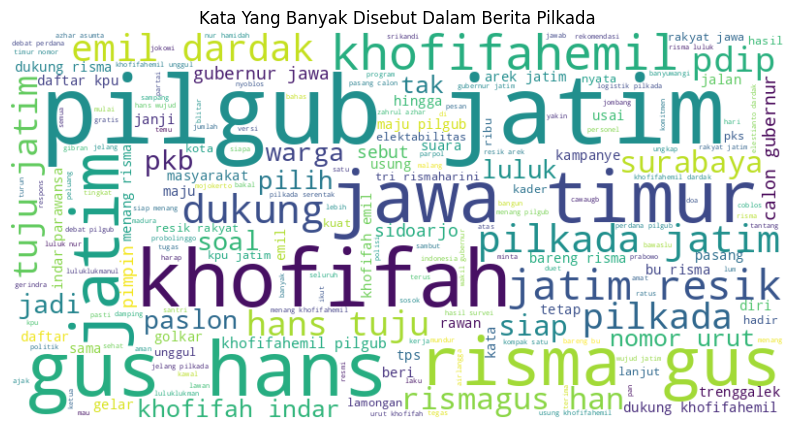

In [ ]:
# Word Cloud Keseluruhan
datax=df
datax['text22'] = datax['token_clean'].apply(lambda x: str(x).replace('[', '').replace(']', '').replace(',', '').replace("'",''))
#datax.head()
text2 = ' '.join(datax['text22'].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text2)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Kata Yang Banyak Disebut Dalam Berita Pilkada')
plt.show()

In [ ]:
s0 = df.loc[df['category'] == 'paslon 1'] # Paslon 1
s1 = df.loc[df['category'] == 'paslon 2'] # Paslon 2
s2 = df.loc[df['category'] == 'paslon 3'] # Paslon 3

In [ ]:
print(df.loc[df['category'] == 'paslon 1', 'token_clean'].head())

121    [tiga, paslon, paham, soal, isu, perspektif, g...
163    [damping, suami, luluk, pilih, coblos, tps, sd...
168    [tanah, lahir, ini, akan, mulai, langkah, besa...
174    [terus, ikhtiar, baik, jawa, timur, lum, gawe,...
181    [punya, data, fakta, kita, sampai, publik, jug...
Name: token_clean, dtype: object


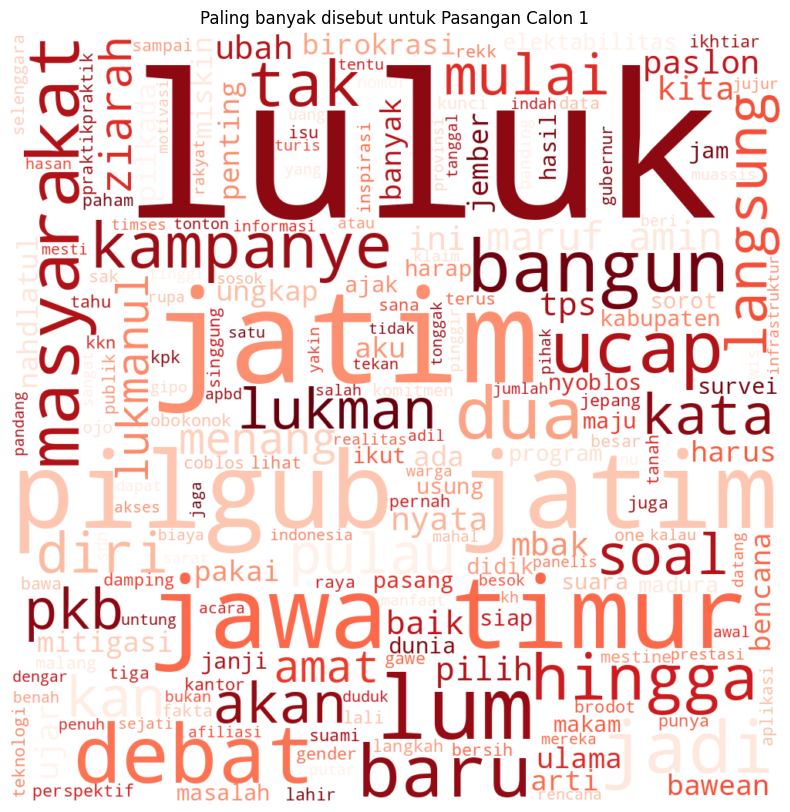

In [ ]:
all_text_s0 = ' '.join([word for sublist in s0['token_clean'] for word in sublist])

# Generate the word cloud
wordcloud = WordCloud(colormap='Reds', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s0)

# Plot the word cloud
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Paling banyak disebut untuk Pasangan Calon 1")
plt.margins(x=0, y=0)
plt.show()

In [ ]:
print(df.loc[df['category'] == 'paslon 2', 'token_clean'].head())

0    [pks, jatim, siap, lanjut, kolaborasi, khofifa...
1    [tasyakur, doa, sama, anak, yatim, atas, menan...
2    [tasyakur, doa, sama, anak, yatim, atas, menan...
3    [khofifahemil, raih, persen, suara, pilgub, ja...
5    [count, poltracking, pilgub, jatim, persen, kh...
Name: token_clean, dtype: object


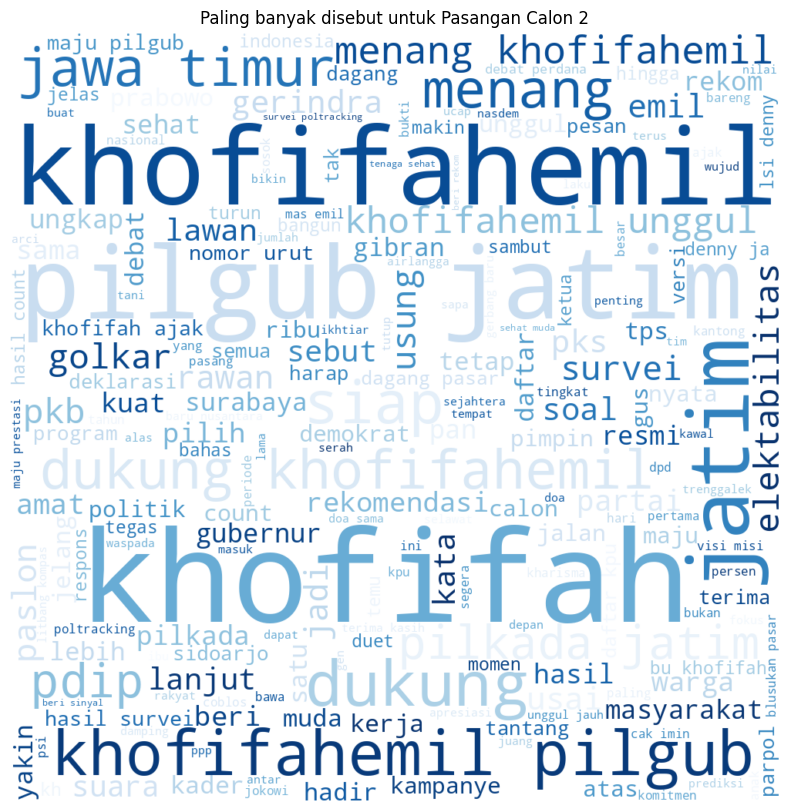

In [ ]:
all_text_s1 = ' '.join([word for sublist in s1['token_clean'] for word in sublist])

# Generate the word cloud
wordcloud = WordCloud(colormap='Blues', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s1)

# Plot the word cloud
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Paling banyak disebut untuk Pasangan Calon 2")
plt.margins(x=0, y=0)
plt.show()

In [ ]:
print(df.loc[df['category'] == 'paslon 3', 'token_clean'].head())

72     [tumbang, pilgub, rismagus, hans, batal, resik...
125    [hasto, rasa, arus, balik, dukung, rismagus, h...
133    [megawati, ultimatum, kader, pdip, menang, ris...
162           [tps, rismagus, hans, unggul, raih, suara]
164    [saya, minta, keluarga, ke, diri, sana, saya, ...
Name: token_clean, dtype: object


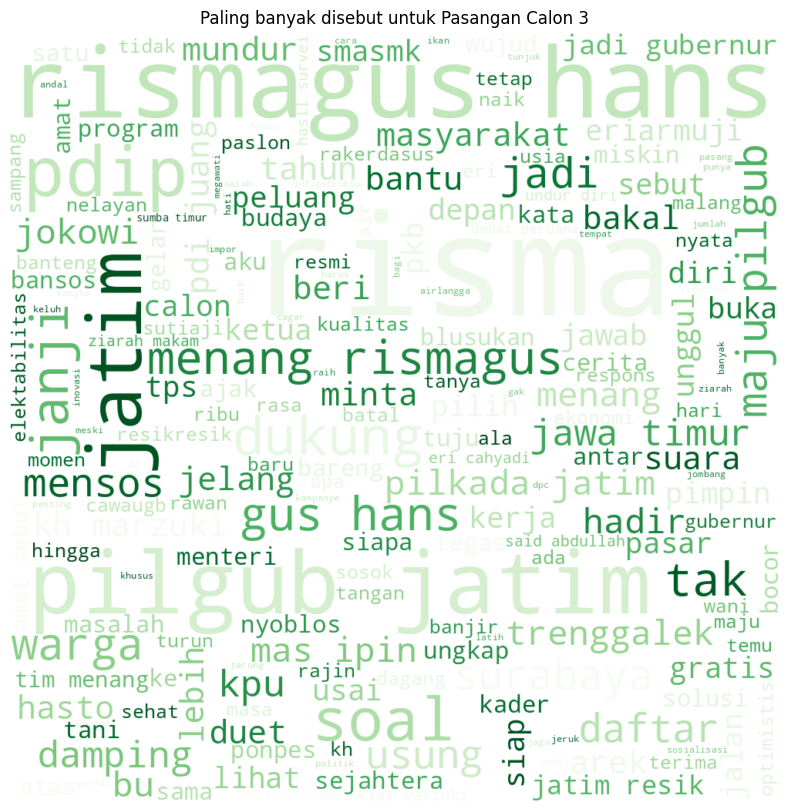

In [ ]:
all_text_s2 = ' '.join([word for sublist in s2['token_clean'] for word in sublist])

# Generate the word cloud
wordcloud = WordCloud(colormap='Greens', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s2)

# Plot the word cloud
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Paling banyak disebut untuk Pasangan Calon 3")
plt.margins(x=0, y=0)
plt.show()

# SENTIMENT

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Additional lexicon ID
additional_lexicon_id = {
    'siap': 0.8,
    'kolaborasi': 0.7,
    'bangun': 0.9,
    'prestasi': 0.9,
    'tegas': 0.8,
    'komitmen': 0.8,
    'apresiasi': 0.9,
    'unggul': 1,
    'dukung': 0.9,
    'menang': 1,
    'doa': 1,
    'inspirasi': 1,
    'hebat': 1,
    'bangga': 1,
    'positif': 1,
    'cerdas' : 1,
    'berprestasi': 1,
    'optimis': 1,
    'santun' : 1,
    'solid': 0.9,
    'maju': 0.9,
    'korupsi': -1,
    'hoaks': -0.9,
    'protes': -0.7,
    'fitnah': -0.8,
    'serang': -0.8,
    'buruk': -1,
    'merugikan': -0.9,
    'benci': -1,
    'kalah': -1,
    'ancaman': -0.9,
    'program': 0.3,
    'kandidat': 0.3,
    'pemilu': 0.3,
    'partai': 0.3,
    'media': 0.3,
    'kampanye': 0.4,
    'visi': 0.4,
    'misi': 0.4,
    'strategi': 0.4,
    'relawan': 0.5,
    'inovasi' : 0.3,
    'populer' : 0.5
}

# Update analyzer with the new lexicon
analyzer.lexicon.update(additional_lexicon_id)

# Fungsi untuk mendapatkan kategori sentimen
def get_sentiment_category(text):
    compound_score = analyzer.polarity_scores(text)['compound']
    if compound_score > 0:
        return 'Positif'
    elif compound_score < 0:
        return 'Negatif'
    else:
        return 'Netral'
# Apply the function to create the 'Sentiment Baru' column
df['Sentiment'] = df['title'].apply(get_sentiment_category)

df[['title', 'category', 'Sentiment']]

,title,category,Sentiment
0,pks jatim siap lanjutkan kolaborasi dengan kho...,paslon 2,Positif
1,tasyakuran dan doa bersama anak yatim atas kem...,paslon 2,Positif
2,tasyakuran dan doa bersama anak yatim atas kem...,paslon 2,Positif
3,khofifahemil raih persen suara di pilgub jatim...,paslon 2,Positif
4,quick count poltracking khofifahemil unggul di...,paslon 2 paslon 2,Positif
...,...,...,...
2053,hasil pilkada di mojokerto khofifah dan gus ba...,paslon 2,Positif
2054,pkb usung kader maju pilgub jatim luluk nur ha...,paslon 1 paslon 1 paslon 1,Positif
2055,luluk nur hamidah ingin bangun krl di madura r...,paslon 1 paslon 1 paslon 1,Positif
2056,maju pilgub jatim luluk hamidah serahkan surat...,paslon 1 paslon 1,Positif


# SENTIMENT DISTRIBUTION

In [ ]:
# TF-IDF

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['Sentiment'])

In [ ]:
temp = df.groupby('Sentiment').count()['title'].reset_index().sort_values(by='title',ascending=False)
temp.style.background_gradient(cmap='inferno_r')

,Sentiment,title
1,Netral,1453
2,Positif,569
0,Negatif,36


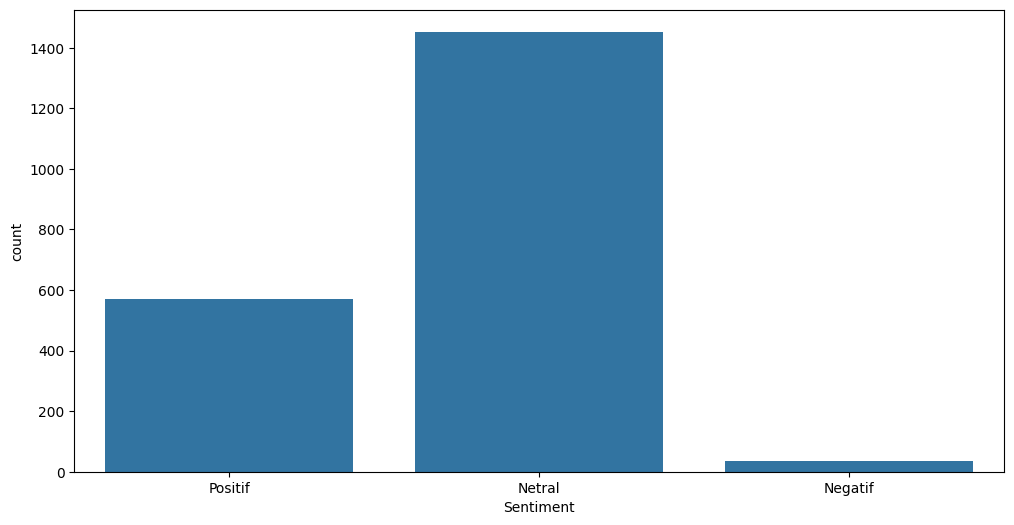

In [ ]:
#diagram
plt.figure(figsize=(12,6))
sns.countplot(x='Sentiment',data=df)
plt.show()

In [ ]:
fig = go.Figure(go.Funnelarea(
    text =temp.Sentiment,
    values = temp.title,
    title = {"position": "top center", "text": "Funnel-Chart dari Distribusi target"}
    ))
fig.show()

# WORD CLOUD SENTIMENT

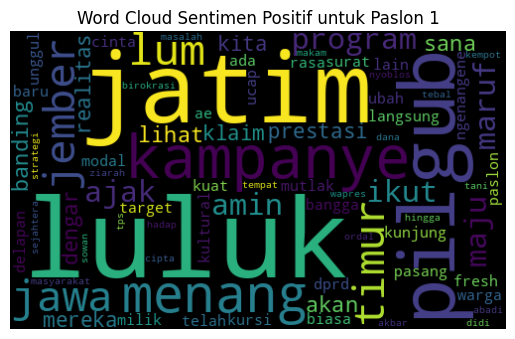

In [ ]:
# WordCloud Sentimen Positif untuk Paslon 1
s0 = df.loc[df['category'] == 'paslon 1']
df_positif_s0 = s0[s0['Sentiment'] == 'Positif']
all_words_positif_s0 = ' '.join([' '.join(i) for i in df_positif_s0['token_clean']])
wordcloud_positif_s0 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_positif_s0)

plt.imshow(wordcloud_positif_s0, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Positif untuk Paslon 1')
plt.show()

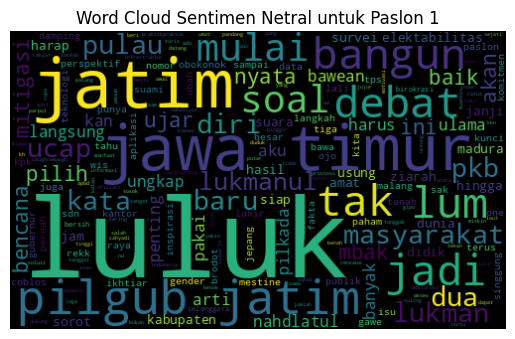

In [ ]:
# WordCloud Sentimen Netral untuk Paslon 1
s0 = df.loc[df['category'] == 'paslon 1']
df_netral_s0 = s0[s0['Sentiment'] == 'Netral']
all_words_netral_s0 = ' '.join([' '.join(i) for i in df_netral_s0['token_clean']])
wordcloud_netral_s0 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_netral_s0)

plt.imshow(wordcloud_netral_s0, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Netral untuk Paslon 1')
plt.show()

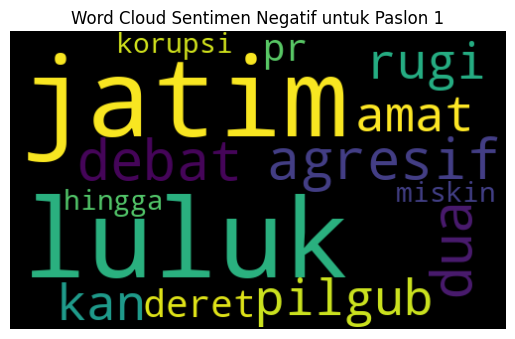

In [ ]:
# WordCloud Sentimen Negatif untuk Paslon 1
s0 = df.loc[df['category'] == 'paslon 1']
df_negatif_s0 = s0[s0['Sentiment'] == 'Negatif']
all_words_negatif_s0 = ' '.join([' '.join(i) for i in df_negatif_s0['token_clean']])
wordcloud_negatif_s0 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_negatif_s0)

plt.imshow(wordcloud_negatif_s0, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Negatif untuk Paslon 1')
plt.show()

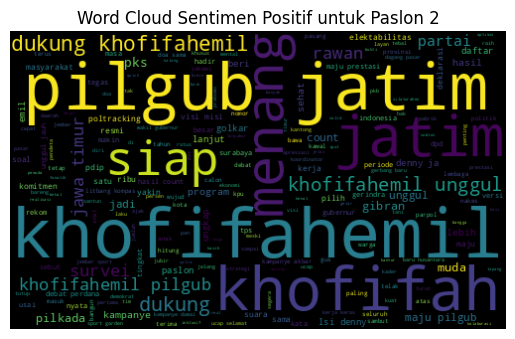

In [ ]:
# WordCloud Sentimen Positif untuk Paslon 2
s1 = df.loc[df['category'] == 'paslon 2']
df_positif_s1 = s1[s1['Sentiment'] == 'Positif']
all_words_positif_s1 = ' '.join([' '.join(i) for i in df_positif_s1['token_clean']])
wordcloud_positif_s1 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_positif_s1)

plt.imshow(wordcloud_positif_s1, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Positif untuk Paslon 2')
plt.show()

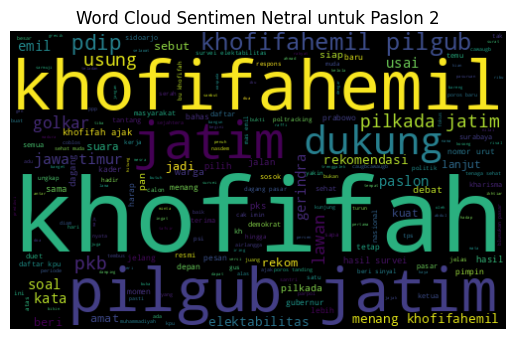

In [ ]:
# WordCloud Sentimen Netral untuk Paslon 2
s1 = df.loc[df['category'] == 'paslon 2']
df_netral_s1 = s1[s1['Sentiment'] == 'Netral']
all_words_netral_s1 = ' '.join([' '.join(i) for i in df_netral_s1['token_clean']])
wordcloud_netral_s1 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_netral_s1)

plt.imshow(wordcloud_netral_s1, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Netral untuk Paslon 2')
plt.show()

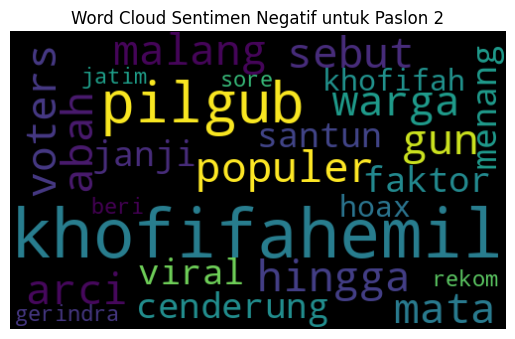

In [ ]:
# WordCloud Sentimen Negatif untuk Paslon 2
s1 = df.loc[df['category'] == 'paslon 2']
df_negatif_s1 = s1[s1['Sentiment'] == 'Negatif']
all_words_negatif_s1 = ' '.join([' '.join(i) for i in df_negatif_s1['token_clean']])
wordcloud_negatif_s1 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_negatif_s1)

plt.imshow(wordcloud_negatif_s1, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Negatif untuk Paslon 2')
plt.show()

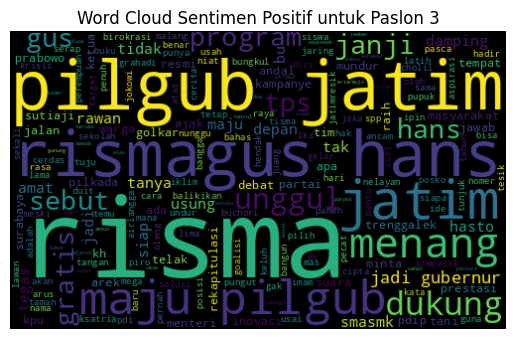

In [ ]:
# WordCloud Sentimen Positif untuk Paslon 3
s2 = df.loc[df['category'] == 'paslon 3']
df_positif_s2 = s2[s2['Sentiment'] == 'Positif']
all_words_positif_s2 = ' '.join([' '.join(i) for i in df_positif_s2['token_clean']])
wordcloud_positif_s2 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_positif_s2)

plt.imshow(wordcloud_positif_s2, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Positif untuk Paslon 3')
plt.show()

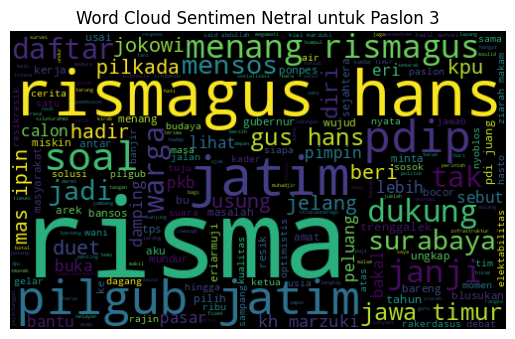

In [ ]:
# WordCloud Sentimen Netral untuk Paslon 3
s2 = df.loc[df['category'] == 'paslon 3']
df_netral_s2 = s2[s2['Sentiment'] == 'Netral']
all_words_netral_s2 = ' '.join([' '.join(i) for i in df_netral_s2['token_clean']])
wordcloud_netral_s2 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_netral_s2)

plt.imshow(wordcloud_netral_s2, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Netral untuk Paslon 3')
plt.show()

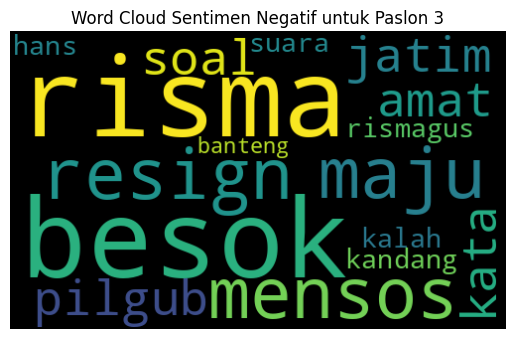

In [ ]:
# WordCloud Sentimen Negatif untuk Paslon 3
s2 = df.loc[df['category'] == 'paslon 3']
df_negatif_s2 = s2[s2['Sentiment'] == 'Negatif']
all_words_negatif_s2 = ' '.join([' '.join(i) for i in df_negatif_s2['token_clean']])
wordcloud_negatif_s2 = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_negatif_s2)

plt.imshow(wordcloud_negatif_s2, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud Sentimen Negatif untuk Paslon 3')
plt.show()

# SENTIMENT VISUALIZATION

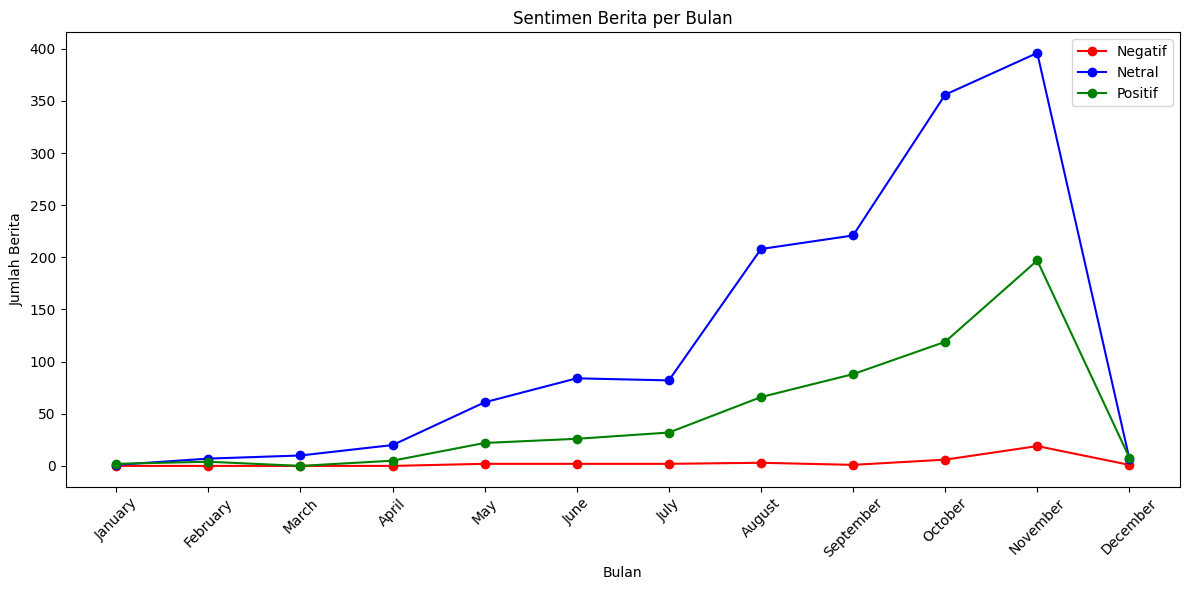

In [ ]:
sentimen_per_bulan = df.groupby(['month', 'Sentiment']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))

# Warna untuk setiap sentimen
warna_sentimen = {
    'Positif': 'green',
    'Netral': 'blue',
    'Negatif': 'red'
}

for sentimen in sentimen_per_bulan.columns:
    plt.plot(sentimen_per_bulan.index, sentimen_per_bulan[sentimen],
             label=sentimen, marker='o', color=warna_sentimen[sentimen])

plt.xlabel('Bulan')
plt.ylabel('Jumlah Berita')
plt.title('Sentimen Berita per Bulan')
plt.xticks(sentimen_per_bulan.index,
           [month_mapping[m] for m in sentimen_per_bulan.index],
           rotation=45)  # Menggunakan month_mapping untuk nama bulan
plt.legend()
plt.tight_layout()
plt.show()

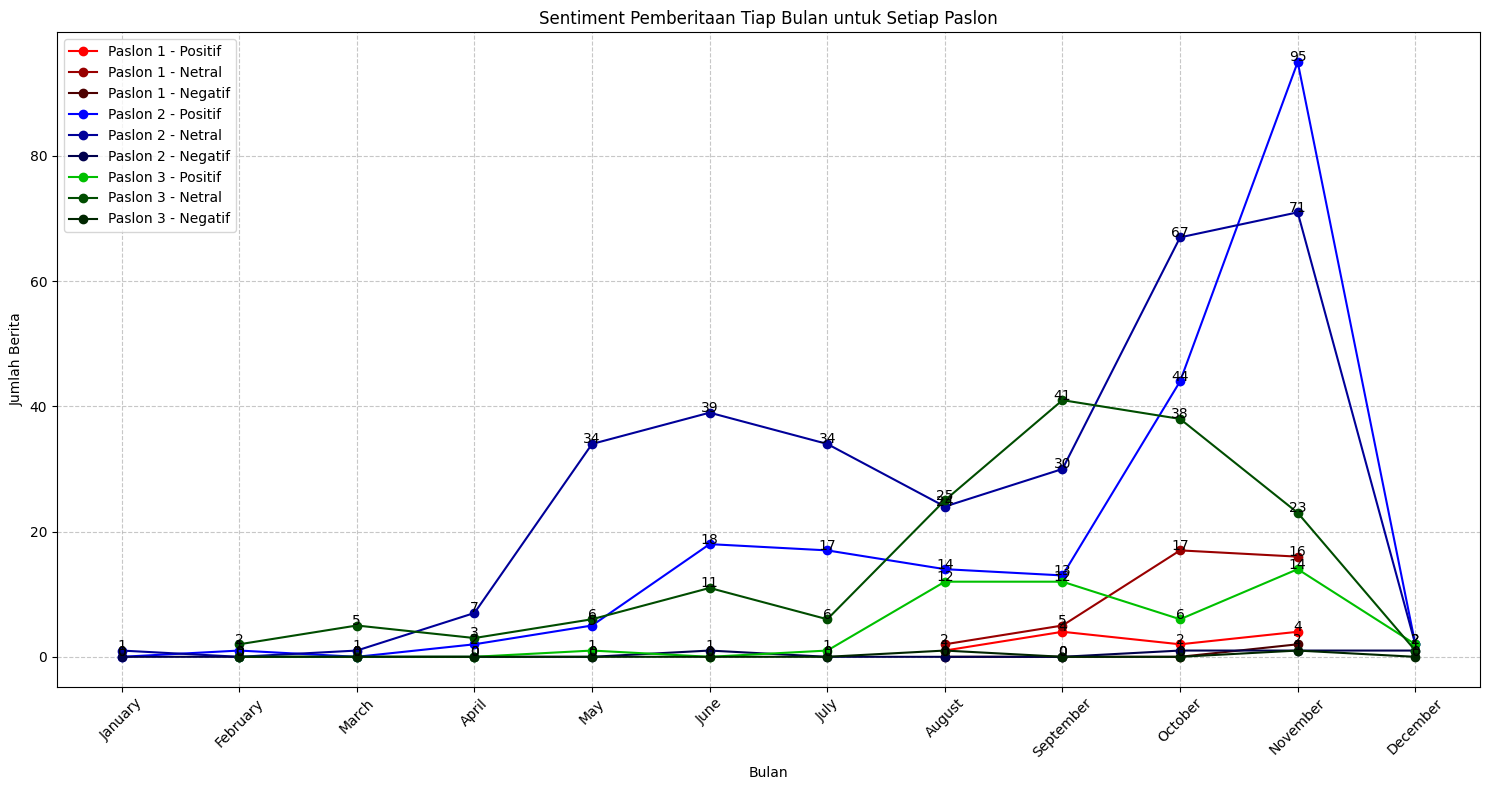

In [ ]:
# Group data by month, category, and sentiment
sentiment_counts = df.groupby(['month', 'category', 'Sentiment']).size().unstack(fill_value=0)

# Reset index to make 'month' a regular column
sentiment_counts = sentiment_counts.reset_index()

# Convert column names to lowercase to match the category names
sentiment_counts.columns = [col.lower() if col != 'month' else col for col in sentiment_counts.columns]

# Convert 'category' column to lowercase for filtering
sentiment_counts['category'] = sentiment_counts['category'].str.lower()

# Plotting
plt.figure(figsize=(15, 8))

# Define colors for paslon
paslon_colors = {
    'paslon 1': 'red',
    'paslon 2': 'blue',
    'paslon 3': 'green'
}


# Define sentiment color variations (adjust as needed)
sentiment_variations = {
    'positif': 1.5,
    'netral': 0.6,
    'negatif': 0.3
}

# Iterate over each category (paslon)
for category in words_to_count:
    base_color = paslon_colors[category.lower()]  # Get base color for the paslon

    for sentiment in ['Positif', 'Netral', 'Negatif']:
        # Filter data for current category and sentiment
        filtered_data = sentiment_counts[(sentiment_counts['category'] == category.lower())]

        # Convert base color to RGB tuple
        base_color_rgb = matplotlib.colors.to_rgb(base_color)

        # Convert base color to HSV
        base_color_hsv = mcolors.rgb_to_hsv(base_color_rgb)

        # Calculate color variation for sentiment (using HSV)
        color_variation = sentiment_variations[sentiment.lower()]
        sentiment_color_hsv = (base_color_hsv[0],
                              base_color_hsv[1],
                              min(base_color_hsv[2] * color_variation, 1))

        # Convert back to RGB for plotting
        sentiment_color = mcolors.hsv_to_rgb(sentiment_color_hsv)

        # Plot the filtered data with calculated color
        plt.plot(filtered_data['month'], filtered_data[sentiment.lower()],
                 label=f'{category} - {sentiment}', marker='o', color=sentiment_color)

        # Add value labels
        for i in range(len(filtered_data)):
            plt.text(filtered_data['month'].iloc[i], filtered_data[sentiment.lower()].iloc[i] + 0.1,
                     filtered_data[sentiment.lower()].iloc[i], ha='center')


# Customize the plot
plt.xlabel('Bulan')
plt.ylabel('Jumlah Berita')
plt.title('Sentiment Pemberitaan Tiap Bulan untuk Setiap Paslon')
plt.xticks(sentiment_counts['month'].unique(), [month_mapping[m] for m in sentiment_counts['month'].unique()], rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# MODELING

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['Sentiment'], test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1646, 3), (412, 3), (1646,), (412,))

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_train, y_train = smote.fit_resample(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.

/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning:

The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.



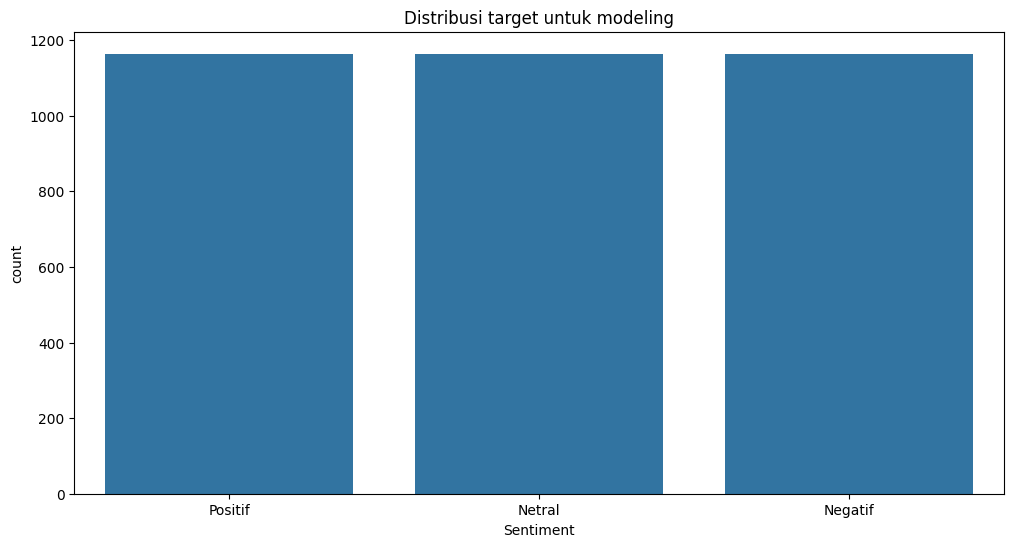

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x=y_train)
plt.title('Distribusi target untuk modeling')
plt.show()

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier # RandomForestClassifier: Ini adalah implementasi algoritma Random Forest untuk klasifikasi dalam scikit-learn
from sklearn.model_selection import RandomizedSearchCV # RandomizedSearchCV: Ini adalah metode untuk melakukan pencarian hyperparameter secara acak untuk model machine learning.

In [ ]:
# Meningkatkan akurasi algoritmma dari Random Forest
rf_param_grid = {'n_estimators': [50, 100, 200], # Ini adalah jumlah (decision trees) yang akan digunakan dalam Random Forest.
                 'max_depth': [None, 10, 20, 30], # Ini menentukan kedalaman maksimum dari setiap decision tree. Mengatur nilai ini dapat membantu mencegah overfitting.
                 'min_samples_split': [2, 5, 10], # Ini adalah jumlah minimum sampel yang dibutuhkan untuk membagi node. Jika jumlah sampel di node kurang dari nilai ini, node tersebut tidak akan dibagi lebih lanjut.
                 'min_samples_leaf': [1, 2, 4]} # Ini membantu dalam meminimalkan overfitting dengan memastikan bahwa ada minimal sejumlah sampel di setiap leaf

In [ ]:
rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                               rf_param_grid, n_iter=10, cv=5,
                               scoring='accuracy', random_state=42)
rf_model.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy')

In [ ]:
print("\nBest Parameters for Random Forest:", rf_model.best_params_)


Best Parameters for Random Forest: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}


# MODEL EVALUATION

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_rf = rf_model.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf) # Hitung akurasi
print(f"\nAccuracy: {accuracy}") # Tampilkan akurasi

print("\n\nClassification Report for Random Forest (Tuned):")
print(classification_report(y_test, y_pred_rf))


Accuracy: 1.0


Classification Report for Random Forest (Tuned):
              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00         5
      Netral       1.00      1.00      1.00       289
     Positif       1.00      1.00      1.00       118

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412

